<a href="https://colab.research.google.com/github/rishikagarg17-byte/starbucks-deep-brew-ai-case-study/blob/main/starbucks_deep_brew_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ☕ Starbucks Deep Brew AI — BBA FinTech Case Study

Educational simulation based on the uploaded case study. It demonstrates customer data, transaction history, feature engineering, collaborative filtering, content-based recommendations, weather-based personalization, a hybrid recommendation engine, bonus-star optimization, and a feedback loop.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Customer Profile Data

In [2]:
customers = pd.DataFrame({
    'customer_id': [101, 102, 103, 104, 105],
    'age': [21, 25, 32, 28, 35],
    'member_tier': ['Gold', 'Silver', 'Gold', 'Bronze', 'Gold'],
    'plant_milk': [1, 0, 1, 0, 1],
    'coffee_preference': ['Cold Brew', 'Latte', 'Iced Matcha', 'Cappuccino', 'Cold Brew']
})
customers

,customer_id,age,member_tier,plant_milk,coffee_preference
0,101,21,Gold,1,Cold Brew
1,102,25,Silver,0,Latte
2,103,32,Gold,1,Iced Matcha
3,104,28,Bronze,0,Cappuccino
4,105,35,Gold,1,Cold Brew


## 2. Transaction History

In [3]:
transactions = pd.DataFrame({
    'customer_id': [101, 101, 102, 102, 103, 103, 104, 105, 105, 105],
    'product': ['Cold Brew', 'Blueberry Muffin', 'Latte', 'Croissant', 'Iced Matcha', 'Cake Pop', 'Cappuccino', 'Cold Brew', 'Brownie', 'Cold Brew'],
    'amount': [250, 180, 220, 160, 240, 120, 210, 250, 150, 250],
    'temperature': [32, 32, 25, 25, 30, 30, 22, 34, 34, 34]
})
transactions

,customer_id,product,amount,temperature
0,101,Cold Brew,250,32
1,101,Blueberry Muffin,180,32
2,102,Latte,220,25
3,102,Croissant,160,25
4,103,Iced Matcha,240,30
5,103,Cake Pop,120,30
6,104,Cappuccino,210,22
7,105,Cold Brew,250,34
8,105,Brownie,150,34
9,105,Cold Brew,250,34


## 3. Product Data

In [4]:
products = pd.DataFrame({
    'product': ['Cold Brew', 'Latte', 'Iced Matcha', 'Cappuccino', 'Croissant', 'Blueberry Muffin', 'Brownie', 'Cake Pop'],
    'category': ['Coffee', 'Coffee', 'Tea', 'Coffee', 'Bakery', 'Bakery', 'Bakery', 'Bakery'],
    'cold_drink': [1, 0, 1, 0, 0, 0, 0, 0],
    'price': [250, 220, 240, 210, 160, 180, 150, 120]
})
products

,product,category,cold_drink,price
0,Cold Brew,Coffee,1,250
1,Latte,Coffee,0,220
2,Iced Matcha,Tea,1,240
3,Cappuccino,Coffee,0,210
4,Croissant,Bakery,0,160
5,Blueberry Muffin,Bakery,0,180
6,Brownie,Bakery,0,150
7,Cake Pop,Bakery,0,120


## 4. Feature Engineering

In [5]:
customer_summary = transactions.groupby('customer_id').agg(
    total_spend=('amount', 'sum'),
    average_order_value=('amount', 'mean'),
    number_of_orders=('product', 'count')
).reset_index()

customer_data = customers.merge(customer_summary, on='customer_id', how='left')
customer_data

,customer_id,age,member_tier,plant_milk,coffee_preference,total_spend,average_order_value,number_of_orders
0,101,21,Gold,1,Cold Brew,430,215.000000,2
1,102,25,Silver,0,Latte,380,190.000000,2
2,103,32,Gold,1,Iced Matcha,360,180.000000,2
3,104,28,Bronze,0,Cappuccino,210,210.000000,1
4,105,35,Gold,1,Cold Brew,650,216.666667,3


## 5. Collaborative Filtering

In [6]:
interaction_matrix = transactions.pivot_table(
    index='customer_id', columns='product', values='amount', aggfunc='count', fill_value=0
)

similarity_matrix = cosine_similarity(interaction_matrix)
similarity_df = pd.DataFrame(similarity_matrix, index=interaction_matrix.index, columns=interaction_matrix.index)

print('Customer-Product Matrix')
display(interaction_matrix)
print('Customer Similarity Matrix')
display(similarity_df.round(2))

Customer-Product Matrix


product,Blueberry Muffin,Brownie,Cake Pop,Cappuccino,Cold Brew,Croissant,Iced Matcha,Latte
customer_id,,,,,,,,
101,1,0,0,0,1,0,0,0
102,0,0,0,0,0,1,0,1
103,0,0,1,0,0,0,1,0
104,0,0,0,1,0,0,0,0
105,0,1,0,0,2,0,0,0


Customer Similarity Matrix


customer_id,101,102,103,104,105
customer_id,,,,,
101,1.00,0.0,0.0,0.0,0.63
102,0.00,1.0,0.0,0.0,0.00
103,0.00,0.0,1.0,0.0,0.00
104,0.00,0.0,0.0,1.0,0.00
105,0.63,0.0,0.0,0.0,1.00


In [7]:
def collaborative_recommendation(customer_id):
    if customer_id not in interaction_matrix.index:
        return []

    similar_customers = similarity_df[customer_id].sort_values(ascending=False)
    similar_customers = similar_customers[similar_customers.index != customer_id].head(2)

    purchased = set(transactions[transactions['customer_id'] == customer_id]['product'])
    recommendations = []

    for similar_customer in similar_customers.index:
        products_bought = transactions[transactions['customer_id'] == similar_customer]['product'].tolist()
        for product in products_bought:
            if product not in purchased:
                recommendations.append(product)

    return list(dict.fromkeys(recommendations))

print('Collaborative recommendations for Customer 101:')
print(collaborative_recommendation(101))

Collaborative recommendations for Customer 101:
['Brownie', 'Latte', 'Croissant']


## 6. Content-Based Filtering

In [8]:
product_features = products[['category', 'cold_drink', 'price']].copy()

# Compatibility for current and older scikit-learn versions
try:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
except TypeError:
    encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')

category_encoded = encoder.fit_transform(product_features[['category']])
numeric_scaled = StandardScaler().fit_transform(product_features[['cold_drink', 'price']].values)
product_vectors = np.hstack([category_encoded, numeric_scaled])
product_similarity = cosine_similarity(product_vectors)

def content_recommendation(product_name, number=3):
    product_index = products[products['product'] == product_name].index[0]
    scores = list(enumerate(product_similarity[product_index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    return [products.iloc[index]['product'] for index, score in scores[1:number+1]]

print('Products similar to Cold Brew:')
print(content_recommendation('Cold Brew'))

Products similar to Cold Brew:
['Iced Matcha', 'Latte', 'Cappuccino']


## 7. Weather-Based Personalization

In [9]:
def weather_recommendation(temperature):
    if temperature >= 30:
        return ['Cold Brew', 'Iced Matcha', 'Cake Pop']
    elif temperature >= 20:
        return ['Latte', 'Cappuccino', 'Croissant']
    else:
        return ['Cappuccino', 'Latte', 'Brownie']

print('Recommendations at 32°C:')
print(weather_recommendation(32))

Recommendations at 32°C:
['Cold Brew', 'Iced Matcha', 'Cake Pop']


## 8. Hybrid Recommendation Engine

In [10]:
def hybrid_recommendation(customer_id, temperature):
    collaborative = collaborative_recommendation(customer_id)

    customer_orders = transactions[transactions['customer_id'] == customer_id]
    content = []
    if len(customer_orders) > 0:
        favorite_product = customer_orders['product'].value_counts().index[0]
        content = content_recommendation(favorite_product)

    weather = weather_recommendation(temperature)
    recommendations = list(dict.fromkeys(collaborative + content + weather))
    return recommendations[:3]

print('Hybrid recommendations for Customer 101 at 32°C:')
print(hybrid_recommendation(101, 32))

Hybrid recommendations for Customer 101 at 32°C:
['Brownie', 'Latte', 'Croissant']


## 9. Bonus-Star Optimization (Educational RL-Inspired Rule)

In [11]:
def bonus_star_offer(customer_id):
    customer = customer_data[customer_data['customer_id'] == customer_id]
    if customer.empty:
        return 0

    spend = customer.iloc[0]['total_spend']

    if spend >= 600:
        return 10
    elif spend >= 400:
        return 15
    else:
        return 20

for cid in customers['customer_id']:
    print(cid, '->', bonus_star_offer(cid), 'bonus stars')

101 -> 15 bonus stars
102 -> 20 bonus stars
103 -> 20 bonus stars
104 -> 20 bonus stars
105 -> 10 bonus stars


## 10. Complete Deep Brew Simulation

In [12]:
def deep_brew(customer_id, temperature):
    recommendations = hybrid_recommendation(customer_id, temperature)
    stars = bonus_star_offer(customer_id)

    return {
        'customer_id': customer_id,
        'temperature': temperature,
        'recommended_products': recommendations,
        'bonus_star_offer': stars
    }

result = deep_brew(101, 32)

print('==============================')
print('       DEEP BREW RESULT')
print('==============================')
print('Customer ID:', result['customer_id'])
print('Temperature:', result['temperature'], '°C')
print('Recommended Products:', result['recommended_products'])
print('Bonus Star Offer:', result['bonus_star_offer'], 'Stars')

       DEEP BREW RESULT
Customer ID: 101
Temperature: 32 °C
Recommended Products: ['Brownie', 'Latte', 'Croissant']
Bonus Star Offer: 15 Stars


## 11. Feedback Loop

In [13]:
def record_purchase(customer_id, product, amount, temperature):
    global transactions

    new_transaction = pd.DataFrame({
        'customer_id': [customer_id],
        'product': [product],
        'amount': [amount],
        'temperature': [temperature]
    })

    transactions = pd.concat([transactions, new_transaction], ignore_index=True)
    print('New purchase recorded:')
    display(new_transaction)

record_purchase(101, 'Iced Matcha', 240, 32)

print('Updated transaction history:')
display(transactions.tail())

New purchase recorded:


,customer_id,product,amount,temperature
0,101,Iced Matcha,240,32


Updated transaction history:


,customer_id,product,amount,temperature
6,104,Cappuccino,210,22
7,105,Cold Brew,250,34
8,105,Brownie,150,34
9,105,Cold Brew,250,34
10,101,Iced Matcha,240,32


## 12. Simple Visualization

This chart shows total spending by customer.

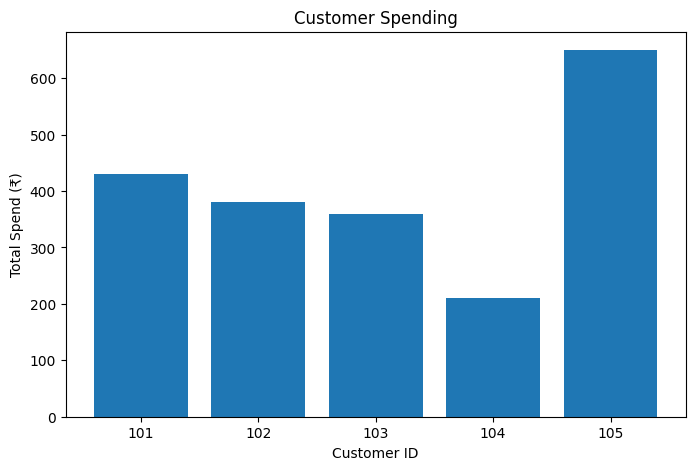

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(customer_data['customer_id'].astype(str), customer_data['total_spend'])
plt.xlabel('Customer ID')
plt.ylabel('Total Spend (₹)')
plt.title('Customer Spending')
plt.show()